Tiles necesarios: ['Copernicus_DSM_COG_10_S40_00_W073_00_DEM', 'Copernicus_DSM_COG_10_S40_00_W072_00_DEM']
DEM: 1500 x 1667 píxeles, z entre 133 y 2854 m


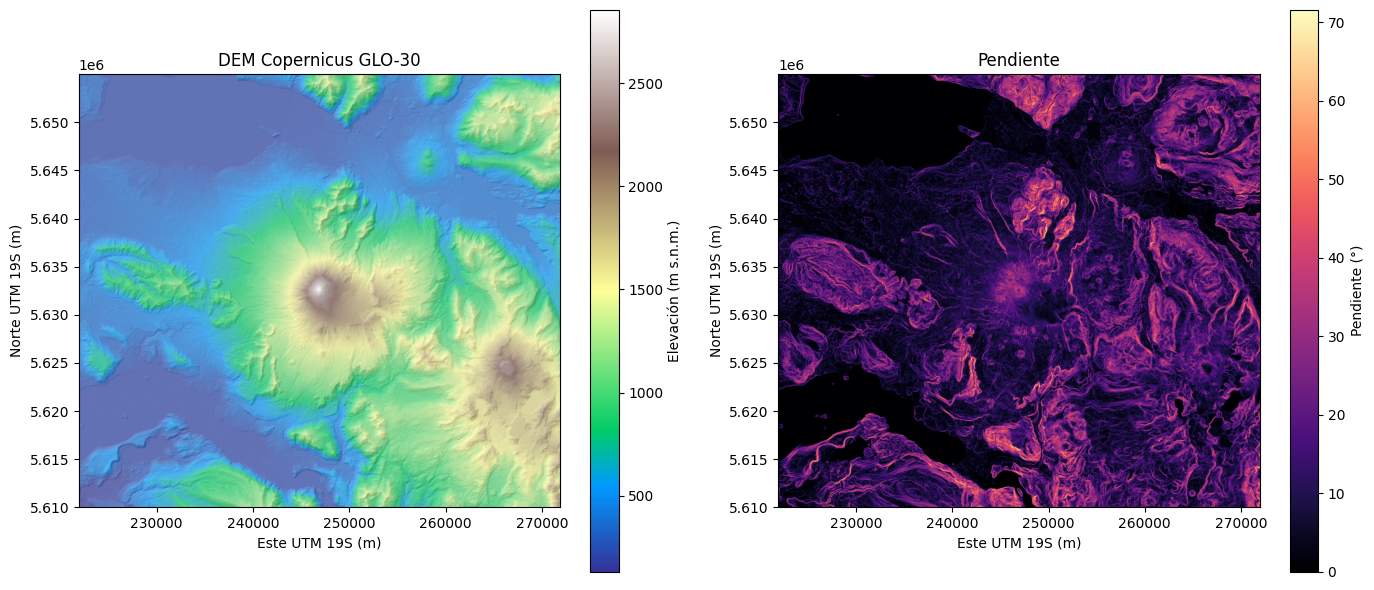

In [2]:
"""
DEM Copernicus GLO-30 (30 m) para el Volcán Villarrica, con tamaño de dominio variable.

Dependencias:
    pip install rasterio numpy matplotlib pyproj

Uso rápido:
    X, Y, Z, tr = get_dem(lon0=-71.94, lat0=-39.42, half_x_km=25, half_y_km=22.5)

Salida:
    X, Y : coordenadas UTM 19S (EPSG:32719) en metros, centros de píxel (2D)
    Z    : elevación en metros (2D, float32, NaN donde no hay dato)
    tr   : transform (affine) del recorte, por si quieres guardarlo como GeoTIFF
"""

import math

import numpy as np
import rasterio
from pyproj import Transformer
from rasterio.merge import merge
from rasterio.transform import array_bounds
from rasterio.warp import Resampling, calculate_default_transform, reproject
from rasterio.windows import from_bounds

UTM_CRS = "EPSG:32719"  # WGS84 / UTM 19S (zona del Villarrica)
BASE_URL = "https://copernicus-dem-30m.s3.amazonaws.com"

_to_utm = Transformer.from_crs("EPSG:4326", UTM_CRS, always_xy=True)
_to_ll = Transformer.from_crs(UTM_CRS, "EPSG:4326", always_xy=True)


# ---------------------------------------------------------------------------
# 1. Utilidades de geometría
# ---------------------------------------------------------------------------
def cop_tiles(bbox):
    """Nombres de los tiles Copernicus (1°x1°) que cubren un bbox (W, S, E, N).

    Cada tile se nombra por su esquina inferior izquierda:
    S40 -> cubre lat -40 a -39 ; W073 -> cubre lon -73 a -72.
    """
    W, S, E, N = bbox
    tiles = []
    for lat in range(math.floor(S), math.ceil(N)):
        for lon in range(math.floor(W), math.ceil(E)):
            ns = f"N{lat:02d}" if lat >= 0 else f"S{-lat:02d}"
            ew = f"E{lon:03d}" if lon >= 0 else f"W{-lon:03d}"
            tiles.append(f"Copernicus_DSM_COG_10_{ns}_00_{ew}_00_DEM")
    return tiles


def bbox_from_center(lon0, lat0, half_x_km, half_y_km=None, margin_km=1.0):
    """Define el dominio en km alrededor de un centro (lon0, lat0).

    Devuelve:
        bbox_ll : (W, S, E, N) en lon/lat con margen, para descargar
        bounds_utm : (xmin, ymin, xmax, ymax) en metros UTM, dominio exacto
    """
    half_y_km = half_y_km if half_y_km is not None else half_x_km
    x0, y0 = _to_utm.transform(lon0, lat0)
    xmin, xmax = x0 - half_x_km * 1e3, x0 + half_x_km * 1e3
    ymin, ymax = y0 - half_y_km * 1e3, y0 + half_y_km * 1e3

    m = margin_km * 1e3
    corners = [
        (xmin - m, ymin - m),
        (xmin - m, ymax + m),
        (xmax + m, ymin - m),
        (xmax + m, ymax + m),
    ]
    lons, lats = zip(*[_to_ll.transform(x, y) for x, y in corners])
    bbox_ll = (min(lons), min(lats), max(lons), max(lats))
    return bbox_ll, (xmin, ymin, xmax, ymax)


# ---------------------------------------------------------------------------
# 2. Descarga, reproyección y recorte
# ---------------------------------------------------------------------------
def get_dem(lon0, lat0, half_x_km, half_y_km=None, res=30):
    """Descarga el DEM Copernicus GLO-30 y lo entrega en UTM 19S, recortado.

    lon0, lat0 : centro del dominio (grados, WGS84)
    half_x_km  : semi-ancho E-O en km (dominio total = 2 * half_x_km)
    half_y_km  : semi-alto N-S en km (por defecto igual a half_x_km)
    res        : tamaño de píxel de salida en metros
    """
    bbox, (xmin, ymin, xmax, ymax) = bbox_from_center(lon0, lat0, half_x_km, half_y_km)
    names = cop_tiles(bbox)
    print(f"Tiles necesarios: {names}")

    # --- Lectura y mosaico (solo lee la ventana del bbox, no el tile completo) ---
    with rasterio.Env(AWS_NO_SIGN_REQUEST="YES", GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR"):
        srcs = [rasterio.open(f"{BASE_URL}/{t}/{t}.tif") for t in names]
        mosaic, tr = merge(srcs, bounds=bbox)
        src_crs = srcs[0].crs
        for s in srcs:
            s.close()
    dem_ll = mosaic[0].astype("float32")

    # --- Reproyección a UTM 19S ---
    h, w = dem_ll.shape
    left, bottom, right, top = array_bounds(h, w, tr)  # límites reales del mosaico
    dst_tr, dw, dh = calculate_default_transform(
        src_crs, UTM_CRS, w, h, left, bottom, right, top, resolution=res
    )
    dem = np.full((dh, dw), np.nan, dtype="float32")
    reproject(
        dem_ll,
        dem,
        src_transform=tr,
        src_crs=src_crs,
        dst_transform=dst_tr,
        dst_crs=UTM_CRS,
        resampling=Resampling.bilinear,
        dst_nodata=np.nan,
    )

    # --- Recorte al rectángulo UTM exacto ---
    win = from_bounds(xmin, ymin, xmax, ymax, transform=dst_tr)
    r0, c0 = int(round(win.row_off)), int(round(win.col_off))
    nr, nc = int(round(win.height)), int(round(win.width))
    if r0 < 0 or c0 < 0 or r0 + nr > dem.shape[0] or c0 + nc > dem.shape[1]:
        raise ValueError(
            "El dominio pedido se sale del DEM descargado; aumenta margin_km "
            "en bbox_from_center()."
        )
    dem = dem[r0 : r0 + nr, c0 : c0 + nc]
    # transform del recorte, alineado a píxeles enteros
    out_tr = rasterio.Affine(
        dst_tr.a, 0.0, dst_tr.c + c0 * dst_tr.a,
        0.0, dst_tr.e, dst_tr.f + r0 * dst_tr.e,
    )

    # --- Coordenadas (centros de píxel) en metros UTM ---
    rows, cols = np.indices(dem.shape)
    X = out_tr.c + (cols + 0.5) * out_tr.a
    Y = out_tr.f + (rows + 0.5) * out_tr.e
    return X, Y, dem, out_tr


# ---------------------------------------------------------------------------
# 3. Guardado y derivadas del terreno
# ---------------------------------------------------------------------------
def save_geotiff(path, Z, tr):
    """Guarda el DEM recortado como GeoTIFF en UTM 19S."""
    with rasterio.open(
        path, "w", driver="GTiff",
        height=Z.shape[0], width=Z.shape[1], count=1, dtype="float32",
        crs=UTM_CRS, transform=tr, nodata=np.nan,
    ) as dst:
        dst.write(Z.astype("float32"), 1)


def terrain_derivatives(Z, tr):
    """dz/dx (este), dz/dy (norte) y pendiente en grados."""
    dx, dy = tr.a, -tr.e  # tr.e es negativo (las filas crecen hacia el sur)
    dzdx = np.gradient(Z, dx, axis=1)
    dzdy = -np.gradient(Z, dy, axis=0)  # signo: filas crecen hacia el sur
    slope = np.degrees(np.arctan(np.hypot(dzdx, dzdy)))
    return dzdx, dzdy, slope


# ---------------------------------------------------------------------------
# 4. Ejemplo de uso
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.colors import LightSource

    # Parámetros del dominio (cambia estos valores para variar el tamaño)
    LON0, LAT0 = -71.94, -39.42      # cerca del cráter (aprox.)
    HALF_X_KM, HALF_Y_KM = 25, 22.5  # dominio de 50 x 45 km
    RES = 30                          # metros por píxel

    X, Y, Z, tr = get_dem(LON0, LAT0, HALF_X_KM, HALF_Y_KM, res=RES)
    print(f"DEM: {Z.shape[0]} x {Z.shape[1]} píxeles, "
          f"z entre {np.nanmin(Z):.0f} y {np.nanmax(Z):.0f} m")

    save_geotiff("villarrica_dem_utm19s.tif", Z, tr)
    dzdx, dzdy, slope = terrain_derivatives(Z, tr)

    # Visualización con relieve sombreado
    extent = (tr.c, tr.c + Z.shape[1] * tr.a, tr.f + Z.shape[0] * tr.e, tr.f)
    hill = LightSource(azdeg=315, altdeg=45).hillshade(
        np.nan_to_num(Z, nan=np.nanmin(Z)), vert_exag=1, dx=tr.a, dy=-tr.e
    )

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    im0 = ax[0].imshow(Z, cmap="terrain", extent=extent)
    ax[0].imshow(hill, cmap="gray", alpha=0.35, extent=extent)
    plt.colorbar(im0, ax=ax[0], label="Elevación (m s.n.m.)")
    ax[0].set_title("DEM Copernicus GLO-30")

    im1 = ax[1].imshow(slope, cmap="magma", extent=extent)
    plt.colorbar(im1, ax=ax[1], label="Pendiente (°)")
    ax[1].set_title("Pendiente")

    for a in ax:
        a.set_xlabel("Este UTM 19S (m)")
        a.set_ylabel("Norte UTM 19S (m)")
    plt.tight_layout()
    plt.show()